In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
plt.style.use(['science','notebook'])

colors = ["#00BBF9", "#CC2836", "#F3A712"]

In [23]:
def compute_IGs(imbalances, correction=False):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [24]:
t_999 = 3.610

In [26]:
subjects = (["001","002","003","004","005","006","007","008","009","010",
             "011","012","013","014","015","016","017","018","019"])
channel_Y = "POz"
E = 12
tau_e = 1
k = 20
t0 = 0
taus = np.arange(0,38)
alphas = np.linspace(0.,50,100)

info_imbalances_X_to_Y = np.zeros((len(subjects),len(taus),len(alphas)))
for i_sub, sub in enumerate(subjects):
    _, info_imbalances_X_to_Y[i_sub] = (
        pickle.load(open(f"./analysis/pickles/pickles_fourth/II_sub{sub}_Xdichotomous_Y{channel_Y}_t0{t0}_E{E}_tauE{tau_e}_k{k}.p","rb"))
    )

# compute Imbalance Gains
IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y)

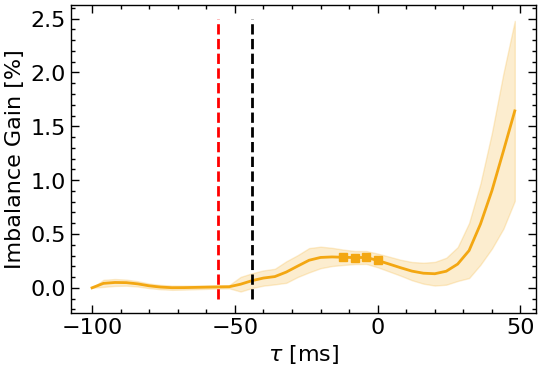

In [16]:
# third dataset
# plot results as a function of tau
taus = np.arange(-25,13)*4
mask_X_to_Y = np.zeros(len(IGs_X_to_Y), dtype=bool)
for itau, _ in enumerate(taus):
    if errors_X_to_Y[itau] != 0:
        mask_X_to_Y[itau] = (IGs_X_to_Y[itau] / errors_X_to_Y[itau]) > t_999

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(taus, IGs_X_to_Y, '-', label=f"$X\\rightarrow ${channel_Y}", color=colors[2])
ax.plot(taus[mask_X_to_Y], IGs_X_to_Y[mask_X_to_Y], 's', label=f"$X\\rightarrow ${channel_Y}", color=colors[2])
ax.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[2], alpha=0.2)
ax.vlines(-44,-0.1,2.5, linestyle="--", color="black")
ax.vlines(-100+44,-0.1,2.5, linestyle="--", color="red")

ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
#ax.legend(loc="upper center")
plt.savefig(f"./figures/IG_onset_Xdichotomous_to_channel{channel_Y}.pdf", dpi=300)
plt.show()

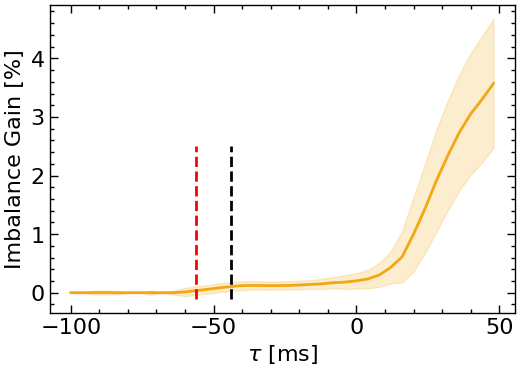

In [27]:
# fourth dataset
# plot results as a function of tau
taus = np.arange(-25,13)*4
mask_X_to_Y = np.zeros(len(IGs_X_to_Y), dtype=bool)
for itau, _ in enumerate(taus):
    if errors_X_to_Y[itau] != 0:
        mask_X_to_Y[itau] = (IGs_X_to_Y[itau] / errors_X_to_Y[itau]) > t_999

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(taus, IGs_X_to_Y, 's-', label=f"$X\\rightarrow ${channel_Y}", color=colors[2])
ax.plot(taus[mask_X_to_Y], IGs_X_to_Y[mask_X_to_Y], 's', label=f"$X\\rightarrow ${channel_Y}", color=colors[2])
ax.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[2], alpha=0.2)
#ax.vlines(-44,-0.1,2.5, linestyle="--", color="black")
#ax.vlines(-100+44,-0.1,2.5, linestyle="--", color="red")

ax.set(xlabel="$\\tau$ [ms]", ylabel="Imbalance Gain [%]")
#ax.legend(loc="upper center")
plt.savefig(f"./figures/IG_onset_Xdichotomous_to_channel{channel_Y}.pdf", dpi=300)
plt.show()

### Final figure

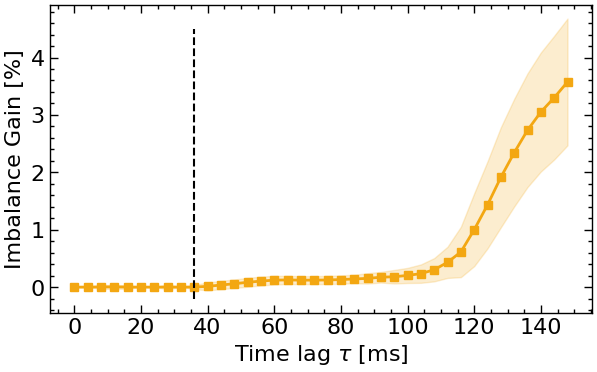

In [38]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

# plot results as a function of tau
taus = 4*np.arange(50-12)#np.arange(-25,13)*4

ax.plot(taus, IGs_X_to_Y, 's-', label=f"$X\\rightarrow ${channel_Y}", color=colors[2])
ax.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, color=colors[2], alpha=0.2)
ax.vlines(80-44,-0.2,4.5, linestyle="--", color="black", linewidth=1.5)

ax.set(xlabel="Time lag $\\tau$ [ms]", ylabel="Imbalance Gain [%]")
ax.set_xticks([0,20,40,60,80,100,120,140])
#ax.legend(loc="upper center")
plt.savefig(f"./figures/IG_onset_Xdichotomous_to_channel{channel_Y}.pdf", dpi=300)
plt.show()